array([0.32105418, 0.07815032])

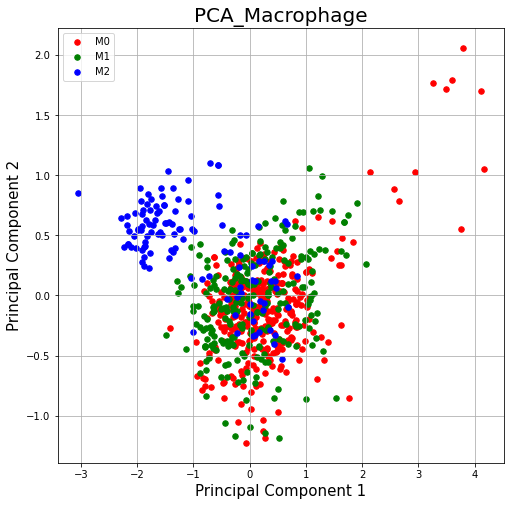

In [56]:
#PCA 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA 
from sklearn import svm
from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder, OneHotEncoder 

#read the data
data = pd.read_csv('macrophage.csv')
#data.head(50)



X_features = data.iloc[:, 1:1301]
y_label = data.iloc[:,0]


#convert the features into the 2 top features
pca = PCA(n_components=2)
principalComponents = pca.fit_transform(X_features)
principalDf = pd.DataFrame(data = principalComponents, columns = ['principal component 1', 'principal component 2'])
principalDf.head(5)
data[['group']].head()
finalDf = pd.concat([principalDf, data[['group']]], axis = 1)
finalDf.head(712)


fig = plt.figure(figsize = (8,8))
ax = fig.add_subplot (1,1,1)
ax.set_xlabel('Principal Component 1', fontsize = 15)
ax.set_ylabel('Principal Component 2', fontsize = 15)
ax.set_title('PCA_Macrophage', fontsize = 20)

targets = ['M0', 'M1', 'M2']
colors = ['r', 'g', 'b']
for target, color in zip(targets,colors):
    indicesToKeep = finalDf['group'] == target
    ax.scatter(finalDf.loc[indicesToKeep, 'principal component 1']
               , finalDf.loc[indicesToKeep, 'principal component 2']
               , c = color
               , s = 30)
    
    ax.legend(targets)
    ax.grid()
pca.explained_variance_ratio_



In [14]:
#decision tree
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn import tree

data = pd.read_csv('macrophage.csv')

X = data.iloc[:, 1:1301]
y = data.iloc[:,0]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state = 100)

model = DecisionTreeClassifier()
model.fit(X_train, y_train)


predictions = model.predict(X_test)
score = accuracy_score(y_test, predictions)

score


0.5664335664335665

In [45]:
# evaluate pca with logistic regression algorithm for classification
from numpy import mean
from numpy import std
from sklearn.datasets import make_classification
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression

# define dataset
data = pd.read_csv('macrophage.csv')
X = data.iloc[:, 1:1301]
y = data.iloc[:,0]

# define the pipeline
steps = [('pca', PCA(n_components=10)), ('m', LogisticRegression())]
model = Pipeline(steps=steps)

# evaluate model
cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=10, random_state=1)
n_scores = cross_val_score(model, X, y, scoring='accuracy', cv=cv, n_jobs=-1, error_score='raise')
# report performance
print('Accuracy: %.3f (%.3f)' % (mean(n_scores), std(n_scores)))

Accuracy: 0.694 (0.051)


>1 0.588 (0.024)
>2 0.610 (0.033)
>3 0.712 (0.053)
>4 0.691 (0.051)
>5 0.696 (0.052)
>6 0.692 (0.052)
>7 0.691 (0.052)
>8 0.692 (0.051)
>9 0.693 (0.051)
>10 0.694 (0.051)
>11 0.695 (0.051)
>12 0.698 (0.058)
>13 0.706 (0.053)
>14 0.706 (0.052)
>15 0.707 (0.054)
>16 0.707 (0.051)
>17 0.707 (0.050)
>18 0.709 (0.052)
>19 0.707 (0.052)
>20 0.708 (0.051)
>21 0.710 (0.053)
>22 0.708 (0.054)
>23 0.710 (0.051)
>24 0.709 (0.049)
>25 0.710 (0.053)
>26 0.714 (0.052)
>27 0.710 (0.050)
>28 0.715 (0.050)
>29 0.715 (0.051)
>30 0.715 (0.048)
>31 0.715 (0.050)
>32 0.713 (0.051)
>33 0.713 (0.050)
>34 0.713 (0.050)
>35 0.714 (0.049)
>36 0.711 (0.052)
>37 0.712 (0.050)
>38 0.713 (0.052)
>39 0.715 (0.050)
>40 0.715 (0.051)
>41 0.716 (0.050)
>42 0.714 (0.049)
>43 0.714 (0.049)
>44 0.715 (0.051)
>45 0.716 (0.053)
>46 0.716 (0.051)
>47 0.717 (0.051)
>48 0.713 (0.050)
>49 0.713 (0.051)
>50 0.717 (0.049)
>51 0.714 (0.050)
>52 0.717 (0.051)
>53 0.717 (0.050)
>54 0.715 (0.052)
>55 0.717 (0.053)
>56 0.719 (0.054)
>

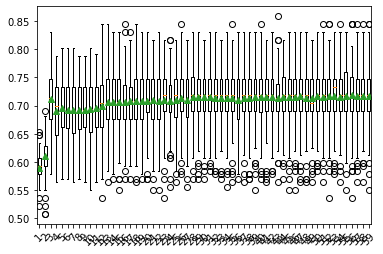

In [46]:
# compare pca number of components with logistic regression algorithm for classification
from numpy import mean
from numpy import std
from sklearn.datasets import make_classification
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from matplotlib import pyplot

# get the dataset
data = pd.read_csv('macrophage.csv')
X = data.iloc[:, 1:1301]
y = data.iloc[:,0]

# get a list of models to evaluate
def get_models():
	models = dict()
	for i in range(1,60):
		steps = [('pca', PCA(n_components=i)), ('m', LogisticRegression())]
		models[str(i)] = Pipeline(steps=steps)
	return models

# evaluate a given model using cross-validation
def evaluate_model(model, X, y):
	cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=10, random_state=1)
	scores = cross_val_score(model, X, y, scoring='accuracy', cv=cv, n_jobs=-1, error_score='raise')
	return scores

# get the models to evaluate
models = get_models()
# evaluate the models and store results
results, names = list(), list()
for name, model in models.items():
	scores = evaluate_model(model, X, y)
	results.append(scores)
	names.append(name)
	print('>%s %.3f (%.3f)' % (name, mean(scores), std(scores)))

# plot model performance for comparison
pyplot.boxplot(results, labels=names, showmeans=True)
pyplot.xticks(rotation=45)
pyplot.show()

>1 0.589 (0.024)
>2 0.611 (0.026)
>3 0.712 (0.054)
>4 0.688 (0.053)
>5 0.689 (0.054)
>6 0.688 (0.052)
>7 0.691 (0.053)
>8 0.698 (0.052)
>9 0.696 (0.052)
>10 0.697 (0.055)
>11 0.699 (0.052)
>12 0.705 (0.055)
>13 0.713 (0.054)
>14 0.716 (0.055)
>15 0.715 (0.056)
>16 0.714 (0.057)
>17 0.717 (0.055)
>18 0.717 (0.055)
>19 0.717 (0.054)
>20 0.716 (0.057)
>21 0.718 (0.055)
>22 0.717 (0.058)
>23 0.718 (0.058)
>24 0.719 (0.054)
>25 0.714 (0.055)
>26 0.716 (0.054)
>27 0.718 (0.056)
>28 0.717 (0.054)
>29 0.719 (0.055)
>30 0.718 (0.054)
>31 0.716 (0.054)
>32 0.718 (0.054)
>33 0.722 (0.057)
>34 0.717 (0.056)
>35 0.722 (0.055)
>36 0.722 (0.053)
>37 0.720 (0.053)
>38 0.722 (0.052)
>39 0.722 (0.052)
>40 0.720 (0.052)
>41 0.719 (0.051)
>42 0.720 (0.050)
>43 0.720 (0.052)
>44 0.720 (0.049)
>45 0.723 (0.051)
>46 0.721 (0.053)
>47 0.721 (0.050)
>48 0.722 (0.054)
>49 0.723 (0.051)
>50 0.723 (0.051)
>51 0.722 (0.049)
>52 0.721 (0.051)
>53 0.723 (0.052)
>54 0.719 (0.050)
>55 0.722 (0.048)
>56 0.721 (0.047)
>

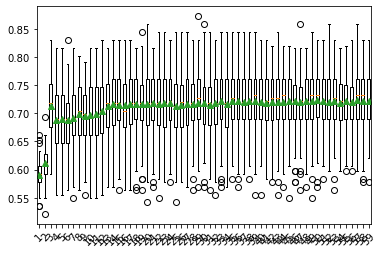

In [47]:
# compare pca number of components with LDA for classification
from numpy import mean
from numpy import std
from sklearn.datasets import make_classification
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from matplotlib import pyplot
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# get the dataset
data = pd.read_csv('macrophage.csv')
X = data.iloc[:, 1:1301]
y = data.iloc[:,0]

# get a list of models to evaluate
def get_models():
	models = dict()
	for i in range(1,60):
		steps = [('pca', PCA(n_components=i)), ('m', LinearDiscriminantAnalysis())]
		models[str(i)] = Pipeline(steps=steps)
	return models

# evaluate a given model using cross-validation
def evaluate_model(model, X, y):
	cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=10, random_state=1)
	scores = cross_val_score(model, X, y, scoring='accuracy', cv=cv, n_jobs=-1, error_score='raise')
	return scores

# get the models to evaluate
models = get_models()
# evaluate the models and store results
results, names = list(), list()
for name, model in models.items():
	scores = evaluate_model(model, X, y)
	results.append(scores)
	names.append(name)
	print('>%s %.3f (%.3f)' % (name, mean(scores), std(scores)))

# plot model performance for comparison
pyplot.boxplot(results, labels=names, showmeans=True)
pyplot.xticks(rotation=45)
pyplot.show()

>1 0.521 (0.060)
>2 0.554 (0.052)
>3 0.714 (0.053)
>4 0.712 (0.046)
>5 0.719 (0.046)
>6 0.717 (0.042)
>7 0.715 (0.050)
>8 0.712 (0.046)
>9 0.711 (0.051)


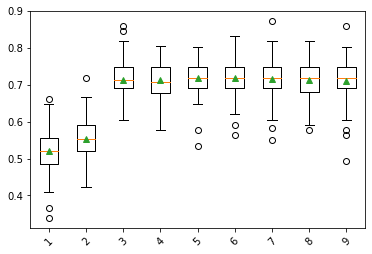

In [66]:
# compare pca number of components with decision tree for classification
from numpy import mean
from numpy import std
from sklearn.datasets import make_classification
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.tree import DecisionTreeClassifier
from matplotlib import pyplot
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# get the dataset
data = pd.read_csv('macrophage.csv')
X = data.iloc[:, 1:1301]
y = data.iloc[:,0]

# get a list of models to evaluate
def get_models():
	models = dict()
	for i in range(1,10):
		steps = [('pca', PCA(n_components=i)), ('d', DecisionTreeClassifier())]
		models[str(i)] = Pipeline(steps=steps)
	return models

# evaluate a given model using cross-validation
def evaluate_model(model, X, y):
	cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=10, random_state=1)
	scores = cross_val_score(model, X, y, scoring='accuracy', cv=cv, n_jobs=-1, error_score='raise')
	return scores

# get the models to evaluate
models = get_models()
# evaluate the models and store results
results, names = list(), list()
for name, model in models.items():
	scores = evaluate_model(model, X, y)
	results.append(scores)
	names.append(name)
	print('>%s %.3f (%.3f)' % (name, mean(scores), std(scores)))

# plot model performance for comparison
pyplot.boxplot(results, labels=names, showmeans=True)
pyplot.xticks(rotation=45)
pyplot.show()